# Equação do calor

Consideremos o problema difusivo homogêneo

$$
\begin{cases}
\dfrac{\partial u}{\partial t} - \alpha \Delta u = 0 & \text{em } \Omega, \\
u = 0 & \text{em } \partial\Omega, \\
u(\cdot, 0) = u_0 & \text{em } \Omega.
\end{cases}
$$

Este é o exemplo mais simples em que aparecem, ao mesmo tempo, discretização
espacial por elementos finitos e discretização temporal por diferenças
finitas.

## Forma fraca no tempo contínuo

Tomando $v \in H_0^1(\Omega)$,

$$
\int_\Omega \frac{\partial u}{\partial t} v \, dx
+
\alpha \int_\Omega \nabla u \cdot \nabla v \, dx
= 0.
$$

A primeira integral carrega a dinâmica temporal. A segunda representa o efeito
difusivo e coincide com a forma de energia típica do operador de Laplace.

## Euler implícito no tempo

Para $t_n = n \Delta t$, aproximamos

$$
\frac{\partial u}{\partial t}(t_{n+1})
\approx
\frac{u^{n+1} - u^n}{\Delta t}.
$$

Isso leva ao esquema:

$$
\int_\Omega u^{n+1} v \, dx
+
\Delta t \, \alpha \int_\Omega \nabla u^{n+1} \cdot \nabla v \, dx
=
\int_\Omega u^n v \, dx.
$$

Em particular, como a difusão é tratada implicitamente, esperamos um método
robusto e com energia decrescente neste caso homogêneo.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from mpi4py import rc

rc.finalize = False

from mpi4py import MPI

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem import petsc

## Escolha do domínio e da condição inicial

Escolhemos

$$
u_0(x, y) = \sin(\pi x)\sin(\pi y),
$$

pois nesse caso existe solução exata explícita:

$$
u(x, y, t) = e^{-2\pi^2 \alpha t}\sin(\pi x)\sin(\pi y).
$$

Isso nos permite comparar o estado final numérico com a solução analítica.

In [2]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 24, 24)
V = fem.functionspace(domain, ("Lagrange", 1))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(domain)

alpha_value = 1.0
dt_value = 0.005
num_steps = 40
final_time = dt_value * num_steps

alpha = fem.Constant(domain, alpha_value)
dt = fem.Constant(domain, dt_value)

u_n = fem.Function(V, name="u_n")
u_n.interpolate(lambda x: np.sin(np.pi * x[0]) * np.sin(np.pi * x[1]))

u_initial = fem.Function(V, name="u_inicial")
u_initial.x.array[:] = u_n.x.array

## Condição de contorno essencial

In [3]:
def boundary(x):
    return (
        np.isclose(x[0], 0.0)
        | np.isclose(x[0], 1.0)
        | np.isclose(x[1], 0.0)
        | np.isclose(x[1], 1.0)
    )


boundary_dofs = fem.locate_dofs_geometrical(V, boundary)
bc = fem.dirichletbc(0.0, boundary_dofs, V)

## Sistema linear em cada passo de tempo

Com a discretização escolhida, resolvemos no passo $n+1$ o problema:

$$
a(u_h^{n+1}, v_h) = L_n(v_h).
$$

In [4]:
a = (u * v + dt * alpha * ufl.inner(ufl.grad(u), ufl.grad(v))) * ufl.dx
L = u_n * v * ufl.dx

problem = petsc.LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="heat_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)

## Evolução temporal e diagnósticos

Vamos acompanhar:

- a energia discreta $E_h^n = \int_\Omega (u_h^n)^2\,dx$;
- o campo final;
- o erro em relação à solução analítica no tempo final.

In [5]:
energies = np.empty(num_steps + 1)
energies[0] = float(fem.assemble_scalar(fem.form(u_n**2 * ufl.dx)))

times = np.linspace(0.0, final_time, num_steps + 1)

for step in range(1, num_steps + 1):
    u_h = problem.solve()
    u_h.x.scatter_forward()
    u_n.x.array[:] = u_h.x.array
    energies[step] = float(fem.assemble_scalar(fem.form(u_h**2 * ufl.dx)))

u_exact_final = fem.Function(V, name="u_ex_tfinal")
u_exact_final.interpolate(
    lambda x: np.exp(-2.0 * np.pi**2 * alpha_value * final_time)
    * np.sin(np.pi * x[0])
    * np.sin(np.pi * x[1])
)

error_h = fem.Function(V, name="erro")
error_h.x.array[:] = u_n.x.array - u_exact_final.x.array

l2_error = fem.assemble_scalar(fem.form((u_n - u_exact_final) ** 2 * ufl.dx)) ** 0.5

print(f"tempo final: {final_time:.3f}")
print(f"energia inicial: {energies[0]:.6e}")
print(f"energia final:   {energies[-1]:.6e}")
print(
    "energia decrescente:",
    all(b <= a + 1e-12 for a, b in zip(energies, energies[1:])),
)
print(f"Erro L2 no tempo final: {l2_error:.6e}")

tempo final: 0.200
energia inicial: 2.485772e-01
energia final:   1.293836e-04
energia decrescente: True
Erro L2 no tempo final: 1.754047e-03


## Curva temporal da energia

A monotonicidade não substitui uma análise completa, mas é um diagnóstico
rápido importante: como o problema é puramente difusivo, a energia não deve
crescer.

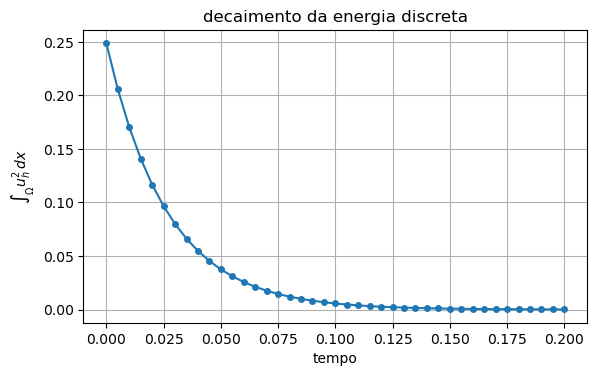

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(times, energies, "o-", ms=4)
ax.set_xlabel("tempo")
ax.set_ylabel(r"$\int_\Omega u_h^2\,dx$")
ax.set_title("decaimento da energia discreta")
ax.grid(True)
plt.show()

## Campos inicial, final numérico, final exato e erro

Aqui a escolha da escala de cores importa bastante. Como os três primeiros
painéis representam a **mesma variável** $u$ em tempos diferentes, usamos a
mesma escala nos três. O erro, por sua vez, ganha uma escala própria.

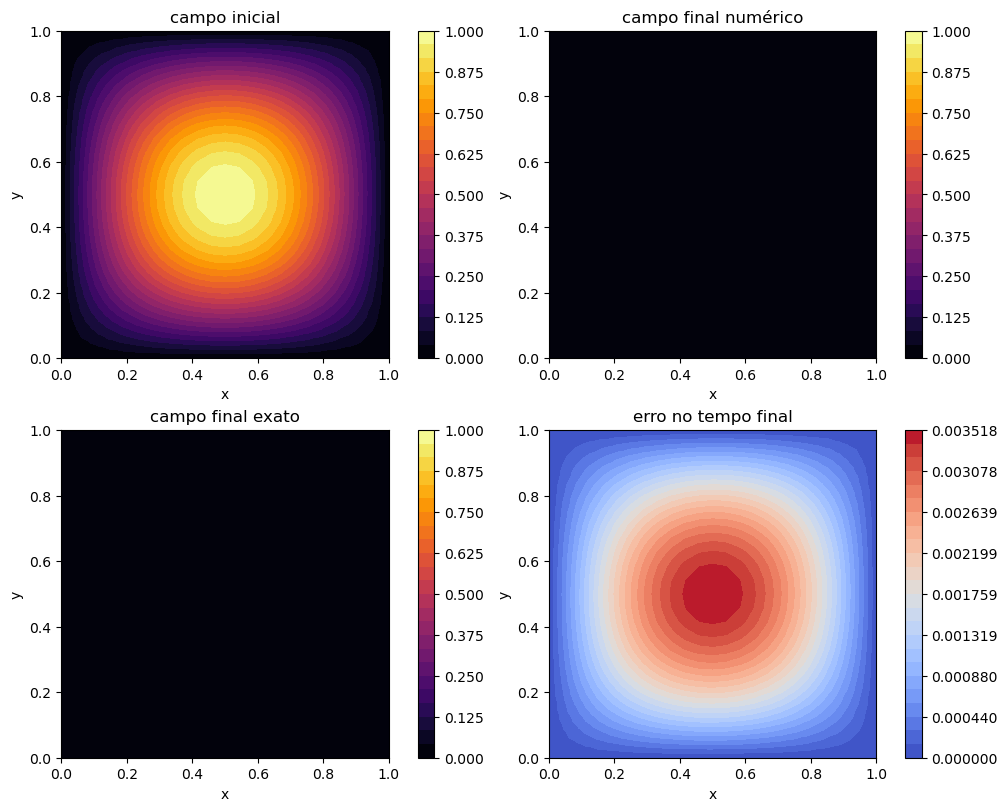

In [7]:
topology, _, geometry = plot.vtk_mesh(V)
triangles = topology.reshape((-1, 4))[:, 1:]
triangulation = mtri.Triangulation(geometry[:, 0], geometry[:, 1], triangles)


def make_shared_levels(*arrays, nlevels=25):
    vmin = min(float(values.min()) for values in arrays)
    vmax = max(float(values.max()) for values in arrays)
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return np.linspace(vmin, vmax, nlevels)


solution_levels = make_shared_levels(
    u_initial.x.array.real,
    u_n.x.array.real,
    u_exact_final.x.array.real,
)
error_levels = make_shared_levels(error_h.x.array.real)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
panels = [
    (axes[0, 0], u_initial, "campo inicial", solution_levels, "inferno"),
    (axes[0, 1], u_n, "campo final numérico", solution_levels, "inferno"),
    (axes[1, 0], u_exact_final, "campo final exato", solution_levels, "inferno"),
    (axes[1, 1], error_h, "erro no tempo final", error_levels, "coolwarm"),
]

for ax, field, title, levels, cmap in panels:
    collection = ax.tricontourf(
        triangulation,
        field.x.array.real,
        levels=levels,
        cmap=cmap,
    )
    fig.colorbar(collection, ax=ax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

plt.show()

## Corte ao longo de $y = 0.5$

Um corte 1D deixa bem clara a redução de amplitude induzida pela difusão e a
proximidade entre solução numérica e solução exata no tempo final.

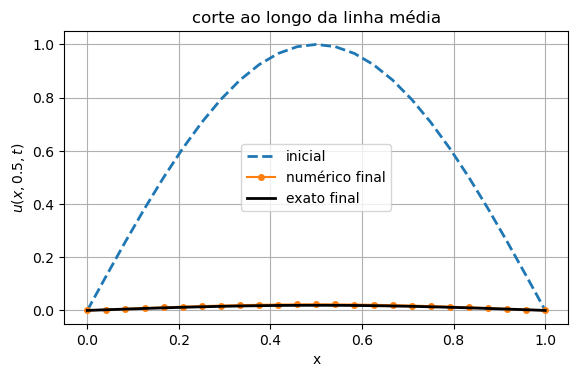

In [8]:
coords = V.tabulate_dof_coordinates()[:, :2]
mask = np.isclose(coords[:, 1], 0.5)
order = np.argsort(coords[mask, 0])
x_cut = coords[mask, 0][order]

u_initial_cut = u_initial.x.array.real[mask][order]
u_final_cut = u_n.x.array.real[mask][order]
u_exact_cut = u_exact_final.x.array.real[mask][order]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(x_cut, u_initial_cut, "--", lw=2, label="inicial")
ax.plot(x_cut, u_final_cut, "o-", ms=4, label="numérico final")
ax.plot(x_cut, u_exact_cut, "-k", lw=2, label="exato final")
ax.set_xlabel("x")
ax.set_ylabel(r"$u(x, 0.5, t)$")
ax.set_title("corte ao longo da linha média")
ax.grid(True)
ax.legend()
plt.show()

## Comentário final

A hipótese mais forte aqui é a regularidade da solução e a homogeneidade do
coeficiente $\alpha$. Em problemas com coeficientes espaciais variáveis,
fontes, geometrias mais complexas ou esquemas adaptativos no tempo, a análise
do método exige um cuidado bem maior.